In [2]:
#importar paquetes
#GUARDAR
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# =========================
# BLOQUE 0: Carga excel
# =========================
file_path = "Slops a T-101 - Históricos 2024 2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Data - Slops a T101")

In [4]:
# =========================
# BLOQUE 1: Separar 2024 y 2025
# =========================
df_2024 = df.iloc[:, 0:2].copy()
df_2025 = df.iloc[:, 2:4].copy()

df_2024.columns = ["Fecha", "Flujo_Slops"]
df_2025.columns = ["Fecha", "Flujo_Slops"]

# Convertir fechas
df_2024["Fecha"] = pd.to_datetime(df_2024["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")
df_2025["Fecha"] = pd.to_datetime(df_2025["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")

In [5]:
# =========================
# BLOQUE 2: Merge vertical
# =========================
df_merged = pd.concat([df_2024, df_2025], axis=0)

df_merged = (
    df_merged
    .dropna(subset=["Fecha"])
    .sort_values("Fecha")
    .drop_duplicates(subset="Fecha")
    .set_index("Fecha")
)

In [6]:
df_merged.head()

,Flujo_Slops
Fecha,
2024-01-01 00:00:00,0.496085
2024-01-01 00:01:00,0.498039
2024-01-01 00:02:00,0.499992
2024-01-01 00:03:00,0.501946
2024-01-01 00:04:00,0.5039


In [7]:
# =========================
# BLOQUE 3: Suma con indentación de NaN
# =========================

# Convertir a numérico textos como "No Good Data For Calculation" = NaN
#columna auxiliar para Flujo_OSBL
df_merged["Flujo_Slops_num"] = pd.to_numeric(df_merged["Flujo_Slops"], errors="coerce")

# Identificar entradas problemáticas:
# 1) No numéricas (NaN)
# 2) Negativos
mask_problem = (
    df_merged["Flujo_Slops_num"].isna() |
    (df_merged["Flujo_Slops_num"] < 0)
)

# Crear columna suma condicional:
#df_merged["Flujo_Total_C3s"] = (
#   df_merged["Flujo_U110_num"] + df_merged["Flujo_Tanques_num"]
#)

# Indentar resultado de suma por NaN (entradas problemáticas)
df_merged.loc[mask_problem, "Flujo_Slops_num"] = np.nan

In [8]:
# =========================
# BLOQUE 4: Preparar datos para graficar
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Convertir a numérico y forzar negativos a NaN
for col in ["Flujo_Slops"]:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

In [9]:
# =========================
# BLOQUE 5.0: Mediana por columna (vector independiente)
# =========================

# Asegurar numérico y negativos como NaN
df_merged["Flujo_Slops"] = pd.to_numeric(df_merged["Flujo_Slops"], errors="coerce")

df_merged.loc[df_merged["Flujo_Slops"] < 0, "Flujo_Slops"] = np.nan

# Medianas individuales
mediana_Slops = df_merged["Flujo_Slops"].median(skipna=True)

print("Mediana Flujo_Slops:", mediana_Slops)

Mediana Flujo_Slops: 1132.5077240762316


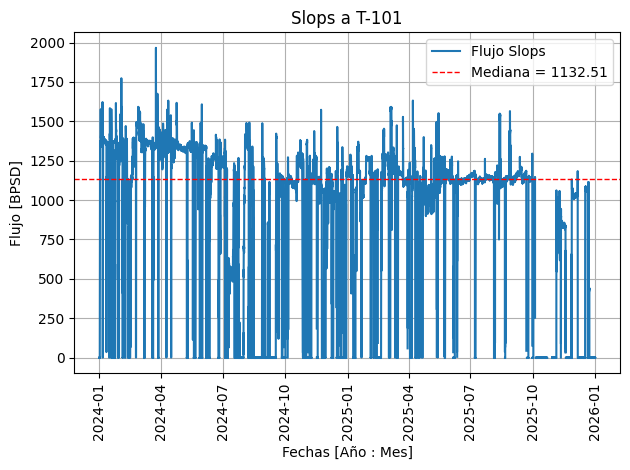

In [13]:
# =========================
# BLOQUE 5.1: Gráfico discontinuo Flujo OSBL
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_Slops"], label="Flujo Slops")

plt.axhline(mediana_Slops, linestyle="--", linewidth=1, color='r',
            label=f"Mediana = {mediana_Slops:.2f}")

plt.xlabel("Fechas [Año : Mes]")
plt.ylabel("Flujo [BPSD]")
plt.xticks(rotation=90)
plt.title("Slops a T-101")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

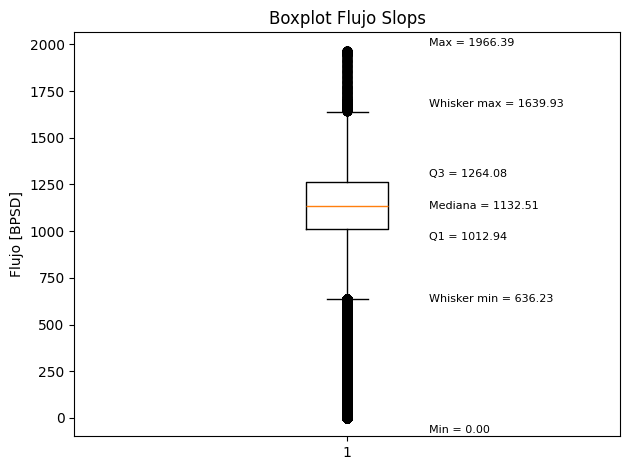

In [14]:
data_Slops = df_merged["Flujo_Slops"].dropna()

box = plt.boxplot(data_Slops, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

q1 = data_Slops.quantile(0.25)
q3 = data_Slops.quantile(0.75)

whiskers = box['whiskers']
low_whisker = whiskers[0].get_ydata()[1] # extremo inferior
high_whisker = whiskers[1].get_ydata()[1] # extremo superior

min_val = data_Slops.min()
max_val = data_Slops.max()

plt.text(1.15, mediana_Slops,
         f"Mediana = {mediana_Slops:.2f}",
         verticalalignment='center', fontsize=8)

plt.text(1.15, q1 - offset, f"Q1 = {q1:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, q3 + offset, f"Q3 = {q3:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, low_whisker, f"Whisker min = {low_whisker:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, high_whisker + offset, f"Whisker max = {high_whisker:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, min_val - 1.5*offset, f"Min = {min_val:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, max_val + offset, f"Max = {max_val:.2f}", verticalalignment='center', fontsize=8)

plt.ylabel("Flujo [BPSD]")
plt.title("Boxplot Flujo Slops")
plt.tight_layout()
plt.show()

In [12]:
columnas = ["Flujo_Slops"]

# Asegurar formato numérico y negativos como NaN
for col in columnas:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

# Crear columna año desde el índice temporal
df_merged["Año"] = df_merged.index.year

# Calcular medianas por año
medianas_por_año = df_merged.groupby("Año")[columnas].median()

print("Medianas por año:")
print(medianas_por_año)

Medianas por año:
      Flujo_Slops
Año              
2024  1192.045711
2025  1125.284502
